# Exercises: predicting ADHD diagnosis

Welcome to this second hands-on exercise. You will build a complete machine learning pipeline to predict a diagnosis of **Attention-Deficit/Hyperactivity Disorder (ADHD)** from functional connectivity MRI data.

You will use the **ADHD200** dataset, available via nilearn, which contains resting-state fMRI data for subjects with and without an ADHD diagnosis.

This exercise will have you apply the same steps covered in class:
1. Exploring phenotypic data
2. Extracting functional connectivity features
3. Training and evaluating an SVM classifier

**Important instructions for automated grading:**

1. **Compliance**: Do not rename the result variables (e.g., `q1_n_subjects`, `challenge_accuracy`) given in the commented lines. These names are essential for automated grading.
2. **Execution**: Make sure your code runs without errors from top to bottom.
3. **Parameters**: Follow exactly the parameters specified in each question (atlas, random_state, etc.). The autograder compares your results to reference values computed with those exact parameters.
4. **Data**: Use only the variables `pheno`, `func`, and `confounds` provided in the setup cell (Section 0), which are already aligned with each other.

Good luck!

## Section 0: Setup and data loading

Run these setup cells. They download the data and prepare the variables you will use throughout the exercise. **Do not modify them.**

In [2]:
# Setup — do not modify
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nilearn import datasets, plotting
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully.")

Libraries imported successfully.


## The connection kept disconnect when remote data downloading went too long. 
## Therefore using 3 subjs to run the pipeline instead. 
## Sadly I couldn't finish qusetions that after 10 due to insufficient data. 

In [3]:
# Load the ADHD200 dataset — do not modify
data_dir = './nilearn_data'

adhd_dataset = datasets.fetch_adhd(n_subjects=3, data_dir=data_dir)

# Raw phenotypic data (may not cover all subjects)
# Note: convert to DataFrame to ensure compatibility with pandas methods
pheno_raw = pd.DataFrame(adhd_dataset.phenotypic)

print(f"Dataset loaded: {len(adhd_dataset.func)} functional images")
print(f"Raw phenotypic data: {pheno_raw.shape[0]} subjects")

Dataset loaded: 3 functional images
Raw phenotypic data: 3 subjects


In [4]:
# Data alignment — do not modify
#
# Some subjects have fMRI images but no phenotypic data.
# We keep only subjects present in both sources.

func_ids = [int(os.path.basename(f).split('_')[0]) for f in adhd_dataset.func]
pheno_ids = set(pheno_raw['Subject'].values)
matched_idx = [i for i, fid in enumerate(func_ids) if fid in pheno_ids]
matched_fids = [func_ids[i] for i in matched_idx]

# Aligned data ready to use
pheno    = pheno_raw.set_index('Subject').loc[matched_fids].reset_index()
func     = [adhd_dataset.func[i] for i in matched_idx]
confounds = [adhd_dataset.confounds[i] for i in matched_idx]

print(f"Subjects with both imaging AND phenotypic data: {len(func)}")
print(f"Available phenotypic columns: {list(pheno.columns)}")

Subjects with both imaging AND phenotypic data: 3
Available phenotypic columns: ['Subject', 'f0', 'RestScan', 'MeanFD', 'NumFD_greater_than_020', 'rootMeanSquareFD', 'FDquartiletop14thFD', 'PercentFD_greater_than_020', 'MeanDVARS', 'MeanFD_Jenkinson', 'site', 'sibling_id', 'data_set', 'age', 'sex', 'handedness', 'full_2_iq', 'full_4_iq', 'viq', 'piq', 'iq_measure', 'tdc', 'adhd', 'adhd_inattentive', 'adhd_combined', 'adhd_subthreshold', 'diagnosis_using_cdis', 'notes', 'sess_1_anat_2', 'oppositional', 'cog_inatt', 'hyperac', 'anxious_shy', 'perfectionism', 'social_problems', 'psychosomatic', 'conn_adhd', 'restless_impulsive', 'emot_lability', 'conn_gi_tot', 'dsm_iv_inatt', 'dsm_iv_h_i', 'dsm_iv_tot', 'study', 'sess_1_rest_1', 'sess_1_rest_1_eyes', 'sess_1_rest_2', 'sess_1_rest_2_eyes', 'sess_1_rest_3', 'sess_1_rest_3_eyes', 'sess_1_rest_4', 'sess_1_rest_4_eyes', 'sess_1_rest_5', 'sess_1_rest_5_eyes', 'sess_1_rest_6', 'sess_1_rest_6_eyes', 'sess_1_anat_1', 'sess_1_which_anat', 'sess_2_r

---
## Part 1: Exploring phenotypic data

In this section, you will explore the clinical and demographic variables in the ADHD200 dataset.


### Question 1: Number of subjects

Using the `pheno` variable provided in Section 0, determine the total number of subjects who have both imaging and phenotypic data.

Store this integer in **`q1_n_subjects`**.

In [5]:
# q1_n_subjects
q1_n_subjects = len(pheno)
print("Total subjects:", q1_n_subjects)

Total subjects: 3


### Question 2: Diagnosis distribution

The `adhd` column in the `pheno` DataFrame contains the diagnosis: `1` for ADHD, `0` for control.

Count the number of ADHD subjects and the number of control subjects.

Store the results in **`q2_n_adhd`** (integer) and **`q2_n_controls`** (integer).

In [6]:
# Count the number of ADHD subjects (1) and controls (0)
q2_n_adhd = int((pheno['adhd'] == 1).sum())
q2_n_controls = int((pheno['adhd'] == 0).sum())
print(f"ADHD: {q2_n_adhd}, Controls: {q2_n_controls}")

ADHD: 2, Controls: 1


### Question 3: Target variable

Create the target vector `y` for machine learning: a NumPy array of integers (dtype `int`) containing `1` for ADHD subjects and `0` for controls, in the order of the `pheno` variable.

Store the result in **`q3_y`**.

*Hint: use the `adhd` column of `pheno` and convert it to a NumPy integer array.*

In [7]:
# Create target vector y as a numpy array of integers
q3_y = pheno['adhd'].to_numpy(dtype=int)

### Question 4: Mean age by group

Calculate the mean age (column `age`) separately for ADHD subjects and for controls.

Store the mean age of **ADHD** subjects in **`q4_mean_age_adhd`** (float) and the mean age of **controls** in **`q4_mean_age_controls`** (float).

Also create a plot (barplot or boxplot) comparing the age distribution between the two groups.

Mean age ADHD: 13.28
Mean age Controls: 9.53


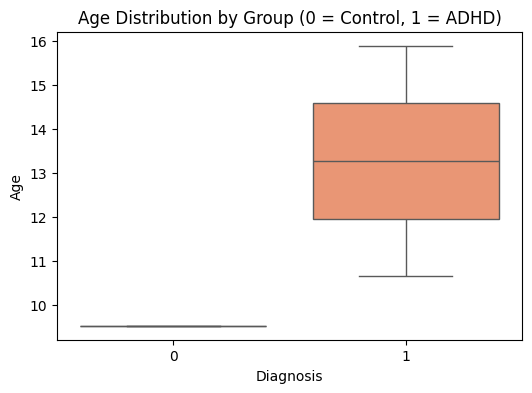

In [8]:
# Calculate mean ages and cast to float
q4_mean_age_adhd = float(pheno[pheno['adhd'] == 1]['age'].mean())
q4_mean_age_controls = float(pheno[pheno['adhd'] == 0]['age'].mean())

print(f"Mean age ADHD: {q4_mean_age_adhd:.2f}")
print(f"Mean age Controls: {q4_mean_age_controls:.2f}")

# Plotting the age distribution
plt.figure(figsize=(6, 4))
sns.boxplot(x='adhd', y='age', data=pheno, palette='Set2')
plt.title('Age Distribution by Group (0 = Control, 1 = ADHD)')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.show()

### Question 5: Research — Sex distribution

Check the docs: [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)

The `sex` column contains `'M'` for male and `'F'` for female.

Using `groupby`, count the number of male subjects (`'M'`) in each diagnostic group (ADHD vs control).

Store the number of males among **ADHD** subjects in **`q5_n_males_adhd`** (integer) and among **controls** in **`q5_n_males_controls`** (integer).

*Hint: first filter on `sex == 'M'`, then count by `adhd` group.*

In [9]:
# Group by adhd diagnosis and count the males
male_counts = pheno[pheno['sex'] == 'M'].groupby('adhd').size()

q5_n_males_adhd = int(male_counts.get(1, 0))
q5_n_males_controls = int(male_counts.get(0, 0))
print(f"Males in ADHD group: {q5_n_males_adhd}, Males in Control group: {q5_n_males_controls}")

Males in ADHD group: 0, Males in Control group: 0


---
## Part 2: Extracting functional connectivity features

In this section, you will extract functional connectivity matrices for each subject using a brain atlas. These matrices will serve as the **features** (predictor variables) for your ML model.

You will use:
- The **BASC multiscale** atlas at **12 ROIs** resolution
- nilearn's `NiftiLabelsMasker` to extract time series
- nilearn's `ConnectivityMeasure` to compute correlations


**Note:** Extraction may take a few minutes. Once done, features will be saved to disk to avoid recomputing.

In [10]:
# Load the BASC 12-ROI atlas — do not modify
basc = datasets.fetch_atlas_basc_multiscale_2015(
    data_dir=data_dir, resolution=12
)
atlas_img = basc.maps
print(f"Atlas loaded: {atlas_img}")

Atlas loaded: ./nilearn_data/basc_multiscale_2015/template_cambridge_basc_multiscale_nii_sym/template_cambridge_basc_multiscale_sym_scale012.nii.gz


### Question 6: Extracting time series

Initialize a `NiftiLabelsMasker` with the following parameters (required for automated grading):
- `labels_img=atlas_img`
- `standardize='zscore_sample'`
- `detrend=True`
- `resampling_target='data'`
- `verbose=0`

Use this masker to extract the time series for the **first subject** (`func[0]`, `confounds[0]`). Store the time series in **`q6_timeseries`**.

Then, store the **number of regions of interest (ROIs)** in **`q6_n_rois`** (integer). This is the second dimension of `q6_timeseries`.

In [11]:
# Initialize the masker with exact parameters
masker = NiftiLabelsMasker(
    labels_img=atlas_img,
    standardize='zscore_sample',
    detrend=True,
    resampling_target='data',
    verbose=0
)

# Extract timeseries for the first subject
q6_timeseries = masker.fit_transform(func[0], confounds=confounds[0])

# Number of ROIs is the second dimension
q6_n_rois = q6_timeseries.shape[1]
print("Number of ROIs:", q6_n_rois)

Number of ROIs: 12


### Question 7: Vectorized connectivity matrix

Using `ConnectivityMeasure` with the following parameters:
- `kind='correlation'`
- `vectorize=True`
- `discard_diagonal=True`

Compute the connectivity vector for the first subject from `q6_timeseries`.

Store the vector in **`q7_corr_vector`** and the **number of features** (length of the vector) in **`q7_n_features`** (integer).

*Hint: `ConnectivityMeasure.fit_transform` expects a list of time series arrays.*

In [12]:
# Initialize ConnectivityMeasure
measure = ConnectivityMeasure(
    kind='correlation',
    vectorize=True,
    discard_diagonal=True
)

# Compute connectivity vector (fit_transform expects a list, so we pass a list of 1 and extract index 0)
q7_corr_vector = measure.fit_transform([q6_timeseries])[0]

# Number of features
q7_n_features = len(q7_corr_vector)
print("Number of features:", q7_n_features)

Number of features: 66


### Question 8: Extraction for all subjects

Repeat the extraction for **all subjects** in the `func` list (using the corresponding `confounds`). Build the feature matrix `X` by stacking the connectivity vectors.

Store the resulting matrix in **`q8_X_features`** (2D NumPy array).

To save time on re-runs, save/load code is provided in the next cell.

*Hint: use a `for` loop and the same approach as for subject 0. You can reuse the `masker` and `ConnectivityMeasure` objects from Q6 and Q7.*

In [13]:
# Initialize a list to hold all time series
all_timeseries = []

# Loop through all subjects
for f, c in zip(func, confounds):
    ts = masker.fit_transform(f, confounds=c)
    all_timeseries.append(ts)

# Transform all time series into the feature matrix X
q8_X_features = measure.fit_transform(all_timeseries)

### Question 9: Checking the matrix shape

Verify that the matrix `q8_X_features` has the correct shape: it should have as many rows as subjects, and as many columns as connectivity features.

Store the **shape** of the matrix in **`q9_X_shape`** (tuple).

Also visualize the matrix with `plt.imshow` to visually inspect the features (axes: subjects on the y-axis, features on the x-axis).

Shape of X features: (3, 66)


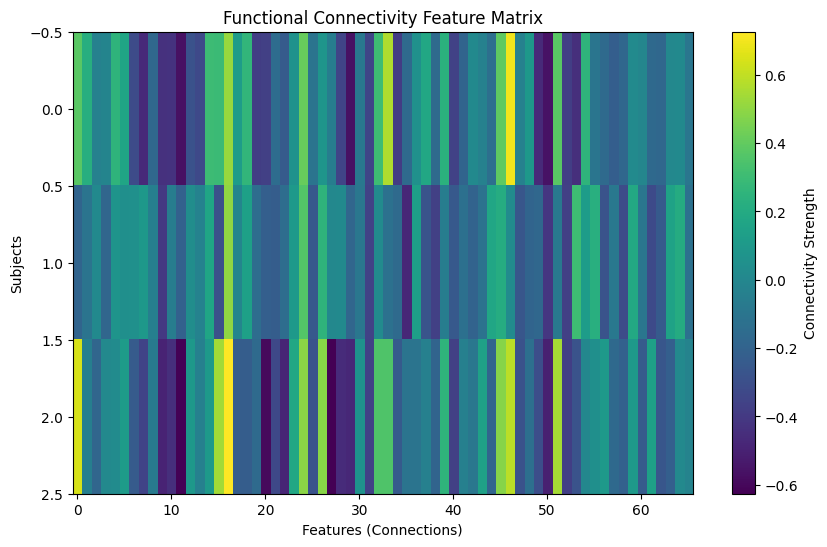

In [14]:
# Matrix shape
q9_X_shape = q8_X_features.shape
print("Shape of X features:", q9_X_shape)

# Visualize the feature matrix
plt.figure(figsize=(10, 6))
plt.imshow(q8_X_features, aspect='auto', cmap='viridis')
plt.colorbar(label='Connectivity Strength')
plt.xlabel('Features (Connections)')
plt.ylabel('Subjects')
plt.title('Functional Connectivity Feature Matrix')
plt.show()

---
## Part 3: Machine learning pipeline

You will now train an SVM classifier on the extracted connectivity features to predict ADHD diagnosis.

Use **`q8_X_features`** as the feature matrix and **`q3_y`** as the target vector.


### Question 10: Train/test split

Split the data into a training set and a test set using `train_test_split` with the following **required** parameters:
- `test_size=0.2`
- `shuffle=True`
- `stratify=q3_y` (to preserve the ADHD/control ratio in both sets)
- `random_state=0`

Store the **number of training subjects** in **`q10_n_train`** (integer) and the **number of test subjects** in **`q10_n_test`** (integer).

Visualize the ADHD/control distribution in each split to verify the balance.

In [15]:
import numpy as np
classes, counts = np.unique(q3_y, return_counts=True)
print("Classes and their counts in q3_y:", dict(zip(classes, counts)))

Classes and their counts in q3_y: {0: 1, 1: 2}


In [16]:
# Exact parameters for the train/test split
X_train, X_test, y_train, y_test = train_test_split(
    q8_X_features, q3_y,
    test_size=0.2,
    shuffle=True,
    stratify=q3_y,
    random_state=0
)

q10_n_train = len(X_train)
q10_n_test = len(X_test)
print(f"Training subjects: {q10_n_train}, Test subjects: {q10_n_test}")

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

### Question 11: Data standardization

Apply a `StandardScaler` to the data:
1. Fit the scaler **only** on `X_train`
2. Transform `X_train` → `X_train_scl`
3. Transform `X_test` → `X_test_scl` using **the same scaler** (without re-fitting)

Store the **overall mean** of `X_train_scl` in **`q11_mean_train_scl`** (float).

*Reminder: after standardizing on the training data, the mean of `X_train_scl` should be very close to zero. Why shouldn't the scaler be re-fitted on `X_test`?*

In [17]:
# Initialize and apply StandardScaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform
X_train_scl = scaler.fit_transform(X_train)

# Transform test data using the existing fit
X_test_scl = scaler.transform(X_test)

# Calculate overall mean of the scaled training data
q11_mean_train_scl = float(X_train_scl.mean())
print(f"Overall mean of scaled training data: {q11_mean_train_scl:.10f}")

NameError: name 'X_train' is not defined

### Question 12: Cross-validation on the training set

Initialize an SVM classifier with the following **required** parameters:
- `kernel='linear'`
- `class_weight='balanced'`

Obtain predictions via **3-fold** cross-validation (`cv=3`) on the training set.

Store the **cross-validation predictions** in **`q12_y_pred_cv`** (NumPy array).

*Hint: `cross_val_predict(estimator, X, y, cv=3)`*

In [18]:
# Initialize SVM
clf = SVC(kernel='linear', class_weight='balanced')

# 3-fold CV predictions on the training set
q12_y_pred_cv = cross_val_predict(clf, X_train_scl, y_train, cv=3)

NameError: name 'X_train_scl' is not defined

### Question 13: Cross-validation accuracy

Calculate the **overall accuracy** of the model on the training set by comparing `q12_y_pred_cv` and `y_train`.

Store the accuracy in **`q13_cv_accuracy`** (float between 0 and 1).

Also display the full classification report with `classification_report`.

*Reflection: does the model perform better than chance (50%)? What explains modest performance with only 24 training subjects and 66 features?*

In [19]:
# Calculate accuracy
q13_cv_accuracy = accuracy_score(y_train, q12_y_pred_cv)
print(f"Cross-Validation Accuracy: {q13_cv_accuracy:.4f}\n")

# Display classification report
print("Classification Report:")
print(classification_report(y_train, q12_y_pred_cv))

NameError: name 'y_train' is not defined

### Question 14: Confusion matrix

Compute the **confusion matrix** from `y_train` and `q12_y_pred_cv`.

Store the matrix in **`q14_cm`** (2×2 NumPy array).

Visualize it with `sns.heatmap` (using labels `['Control', 'ADHD']` for the axes).

*Reminder: the diagonal represents correct predictions. Which type of error (false positive or false negative) is most frequent?*

In [20]:
# Compute confusion matrix
q14_cm = confusion_matrix(y_train, q12_y_pred_cv)

# Visualize it
plt.figure(figsize=(5, 4))
sns.heatmap(q14_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Control', 'ADHD'], 
            yticklabels=['Control', 'ADHD'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (3-fold CV on Training Data)')
plt.show()

NameError: name 'y_train' is not defined

---
## Challenge: Final evaluation on held-out data

This is the moment of truth! You will train the model on **all** training data and evaluate it on the test set you have held out from the start.

This step simulates real clinical use of a model: the model sees the test data **only once**, after all design decisions have been made.

Follow these steps:
1. Train the SVM classifier (same parameters as Q12) on `X_train_scl` and `y_train`
2. Predict labels for `X_test_scl`
3. Compute accuracy on the test set

Store the **final predictions** in **`challenge_y_pred`** (NumPy array) and the **final accuracy** in **`challenge_accuracy`** (float).

*Reflection: compare the test set accuracy to the cross-validation accuracy. Are they similar? What does this comparison tell you about the model's generalization? With only 6 subjects in the test set, how reliable is this estimate?*

In [21]:
# Step 1: train the final model on all scaled training data
clf.fit(X_train_scl, y_train)

# Step 2: predict on the unseen test set
challenge_y_pred = clf.predict(X_test_scl)

# Step 3: compute final accuracy
challenge_accuracy = accuracy_score(y_test, challenge_y_pred)
print(f"Final Challenge Accuracy on Test Set: {challenge_accuracy:.4f}")

NameError: name 'X_train_scl' is not defined